In [2]:
# --- CELL 1: SETUP & DATA PREPARATION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Feature Selection Libraries
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")

print(" Veri Yükleniyor...")
df = pd.read_csv("urban_building_stock_datasets_17042024.csv")

# 1. Leakage Temizliği
leakage_cols = ['Total_Heating_Energy', 'Interior_Lighting_Energy', 'Interior_Equipment_Energy',
                'Heating_Energy', 'Photovoltaic_Power', 'Total_Electricity_Energy',
                'Energy_Use_Intensity', 'Water_Systems_Energy', 'Building_Energy_Rating',
                'Electricity_Primary_Conversion_Factor', 'Heating_Primary_Conversion_Factor']
df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

target = "Simple_Building_Energy_Rating"
X = df.drop(columns=[target])
y = df[target].copy()

# 2. Feature Engineering
X["Global_U_Value"] = (X["Window_Insulation_U-Value"] * X["Window_to_Wall_Ratio"] +
                       X["Wall_Insulation_U-Value"] * (1 - X["Window_to_Wall_Ratio"]))
X["Thermostat_Delta"] = X["Heating_Setpoint_Temperature"] - X["Heating_Setback_Temperature"]
X["Internal_Load_Score"] = (X["Lighting_Density"] + X["Equipment_Density"] +
                            (X["Occupancy_Level"] * 100 / (X["Total_Building_Area"] + 1)))
X["HVAC_Load_Factor"] = X["Total_Building_Area"] / (X["HVAC_Efficiency"] + 0.1)
X["Infiltration_Loss_Potential"] = (X["Air_Change_Rate"] * X["Total_Building_Area"] * X["Thermostat_Delta"])
X["Weighted_Roof_U"] = X["Total_Building_Area"] * X["Roof_Insulation_U-Value"]
X["Orientation_Sin"] = np.sin(np.deg2rad(X["Building_Orientation"]))
X["Orientation_Cos"] = np.cos(np.deg2rad(X["Building_Orientation"]))
X = X.drop(columns=["Building_Orientation"])

# 3. Preprocessing (Chi-Square için MinMax Şart!)
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], verbose_feature_names_out=False)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Transform
X_train = preprocessor.fit_transform(X_train_raw)
feature_names = preprocessor.get_feature_names_out()

print(f" Veri Hazır: {X_train.shape}")

 Veri Yükleniyor...
 Veri Hazır: (838849, 31)


In [3]:
# --- CELL 2: CALCULATE SCORES (CHI2, INFO GAIN, GINI) ---
print("\n 3 Farklı Yöntem Karşılaştırılıyor...")
start_comp = time.time()

# HIZLANDIRMA: %10 Örneklem
# Mutual Information (Info Gain) hesaplaması tüm veride çok yavaştır.
sample_size = int(len(X_train) * 0.10)
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

print(f" Hesaplama {X_sample.shape[0]} satır üzerinde yapılıyor...")

# 1. CHI-SQUARE
print("1️ Chi-Square Hesaplanıyor...")
chi2_scores, _ = chi2(X_sample, y_sample)

# 2. INFORMATION GAIN (Mutual Information)
print("2 Information Gain (Mutual Info) Hesaplanıyor...")
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

# 3. GINI INDEX (Decision Tree Importance)
print("3 Gini Index (Decision Tree) Hesaplanıyor...")
dt = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=10)
dt.fit(X_sample, y_sample)
gini_scores = dt.feature_importances_

# --- NORMALİZASYON ---
# Her yöntemin skor aralığı farklıdır (örn: Chi2 0-1000 arası, Gini 0-1 arası).
# Kıyaslayabilmek için hepsini 0-1 arasına çekiyoruz (Min-Max Scaling).
def normalize(arr):
    if np.max(arr) - np.min(arr) == 0: return arr
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

# DataFrame Oluşturma
df_scores = pd.DataFrame({
    'Feature': feature_names,
    'Chi-Square': normalize(chi2_scores),
    'Info Gain': normalize(mi_scores),
    'Gini Index': normalize(gini_scores)
})

# Ortalama Skor (Consensus) - Sıralama için
df_scores['Mean Score'] = df_scores[['Chi-Square', 'Info Gain', 'Gini Index']].mean(axis=1)
df_scores = df_scores.sort_values(by='Mean Score', ascending=False)

print(f" Hesaplamalar Tamamlandı. Süre: {(time.time() - start_comp):.2f} sn")


 3 Farklı Yöntem Karşılaştırılıyor...
 Hesaplama 83884 satır üzerinde yapılıyor...
1️ Chi-Square Hesaplanıyor...
2 Information Gain (Mutual Info) Hesaplanıyor...
3 Gini Index (Decision Tree) Hesaplanıyor...
 Hesaplamalar Tamamlandı. Süre: 20.67 sn


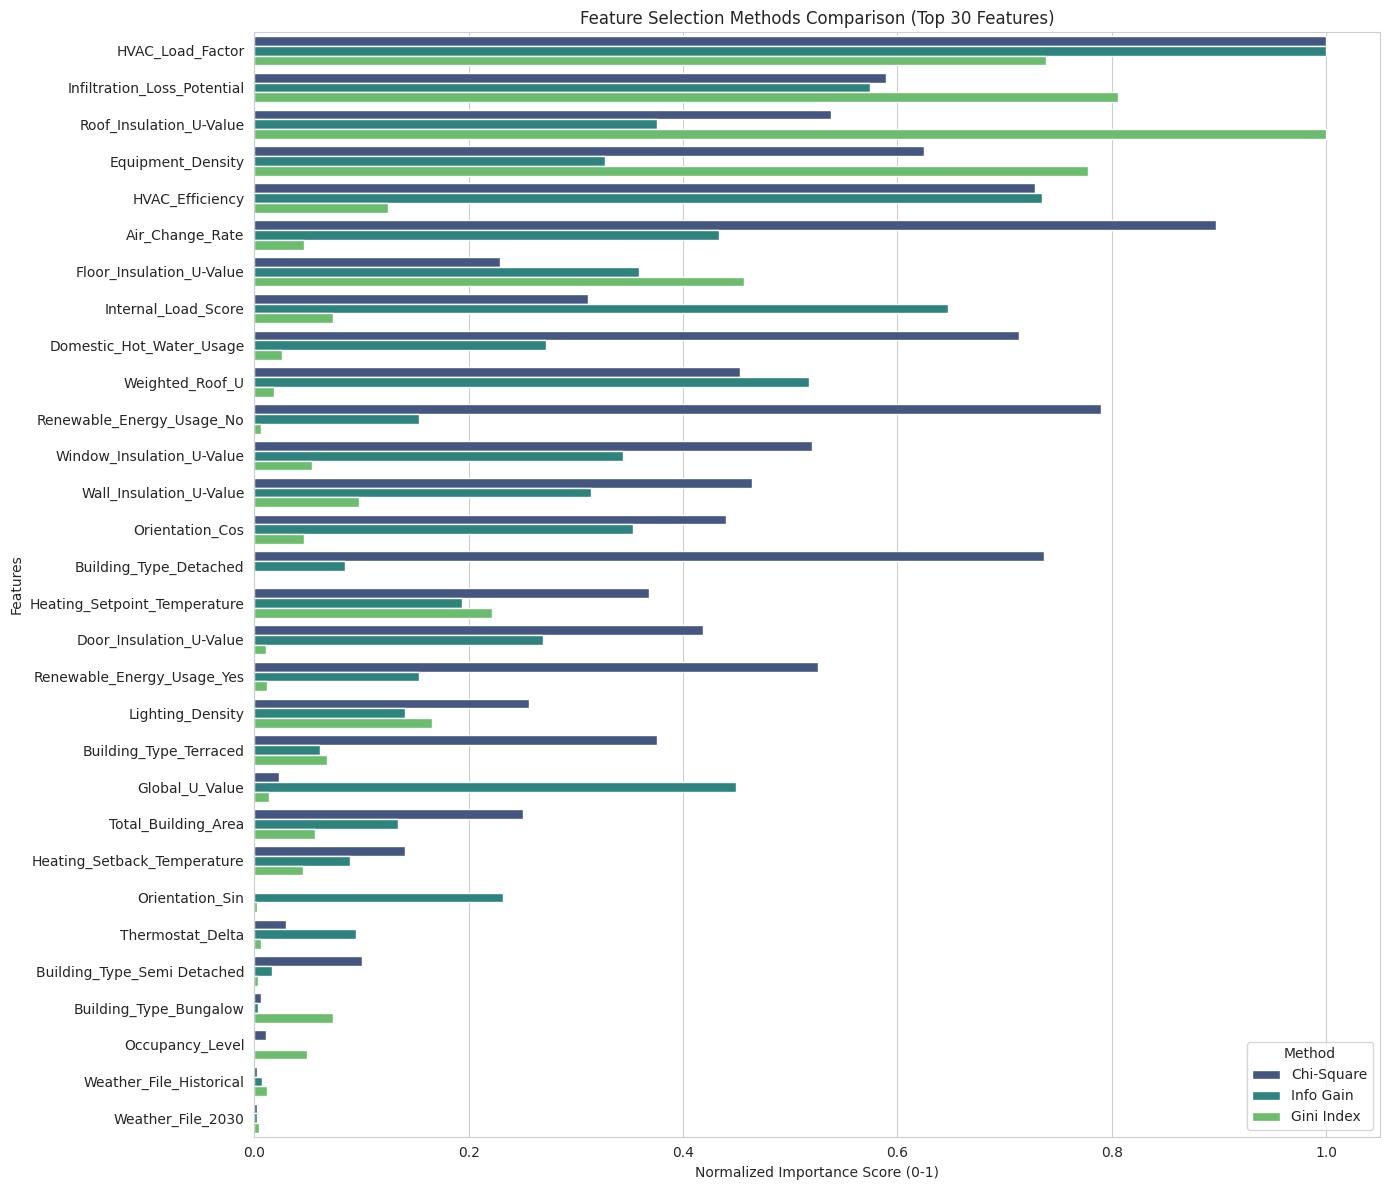


 Feature Importance Comparison Table (Top 15):
                    Feature  Chi-Square  Info Gain  Gini Index  Mean Score
           HVAC_Load_Factor    1.000000   1.000000    0.738645    0.912882
Infiltration_Loss_Potential    0.588817   0.574048    0.805987    0.656284
    Roof_Insulation_U-Value    0.538345   0.375739    1.000000    0.638028
          Equipment_Density    0.624266   0.327518    0.777226    0.576337
            HVAC_Efficiency    0.728193   0.735170    0.124808    0.529391
            Air_Change_Rate    0.896884   0.433415    0.046447    0.458915
   Floor_Insulation_U-Value    0.229723   0.358606    0.457150    0.348493
        Internal_Load_Score    0.311454   0.647308    0.073907    0.344223
   Domestic_Hot_Water_Usage    0.712996   0.271775    0.026327    0.337032
            Weighted_Roof_U    0.452923   0.517235    0.018373    0.329510
  Renewable_Energy_Usage_No    0.790203   0.154092    0.006846    0.317047
  Window_Insulation_U-Value    0.520365   0.344085  

In [6]:
# --- CELL 3: VISUALIZATION & ANALYSIS ---
plt.figure(figsize=(14, 12))

# Veriyi görselleştirme formatına çevir (Melt)
df_melted = df_scores.head(30).melt(
    id_vars='Feature',
    value_vars=['Chi-Square', 'Info Gain', 'Gini Index'],
    var_name='Method',
    value_name='Normalized Score'
)

# Bar Plot
sns.barplot(data=df_melted, x='Normalized Score', y='Feature', hue='Method', palette='viridis')
plt.title('Feature Selection Methods Comparison (Top 30 Features)')
plt.xlabel('Normalized Importance Score (0-1)')
plt.ylabel('Features')
plt.legend(title='Method', loc='lower right')
plt.tight_layout()
plt.show()

# Tabloyu Yazdır
print("\n Feature Importance Comparison Table (Top 15):")
print(df_scores[['Feature', 'Chi-Square', 'Info Gain', 'Gini Index', 'Mean Score']].head(15).to_string(index=False))

# --- ÖNERİ ALGORİTMASI ---
# Hangi yöntemin en mantıklı olduğunu basitçe analiz edelim
top_feature = df_scores.iloc[0]['Feature']
print(f"\n ANALİZ SONUCU:")
print(f"Üç yöntemin ortak kararına göre en önemli özellik: '{top_feature}'")

📊 Özellik Önem Dağılımı Analiz Ediliyor...


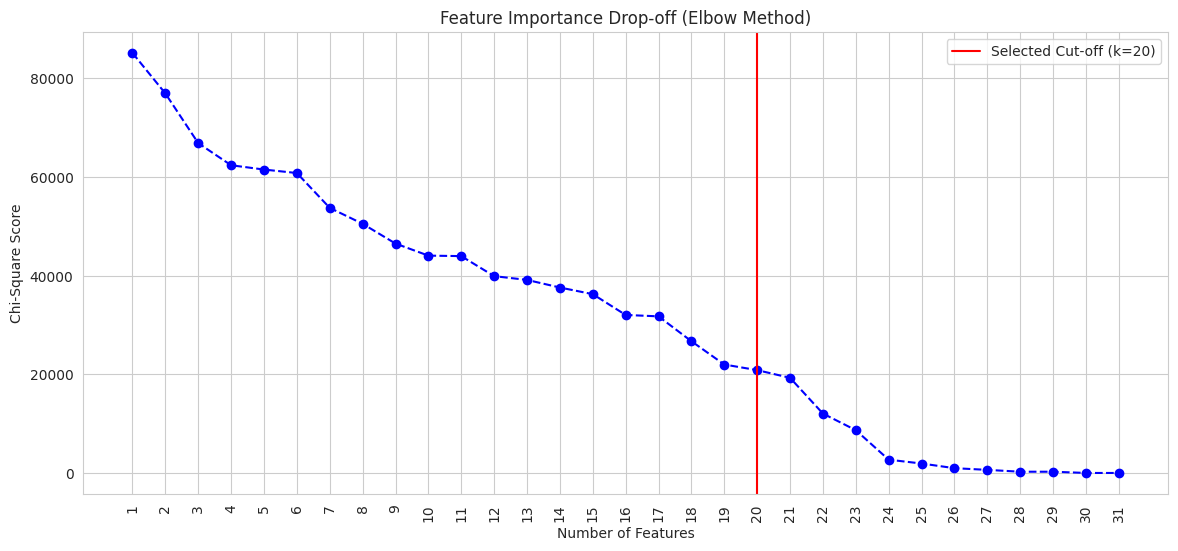

In [8]:
# --- CELL: CHECKING THE ELBOW POINT ---
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import numpy as np

print("📊 Özellik Önem Dağılımı Analiz Ediliyor...")

# Tüm özellikleri puanlayalım (k='all')
selector_all = SelectKBest(score_func=chi2, k='all')
selector_all.fit(X_train, y_train)

# Skorları al ve sırala (Büyükten küçüğe)
scores = selector_all.scores_
indices = np.argsort(scores)[::-1]
sorted_scores = scores[indices]
sorted_features = feature_names[indices]

# Grafiği Çiz
plt.figure(figsize=(14, 6))
plt.plot(range(1, len(scores)+1), sorted_scores, marker='o', linestyle='--', color='b')
plt.title('Feature Importance Drop-off (Elbow Method)')
plt.xlabel('Number of Features')
plt.ylabel('Chi-Square Score')
plt.xticks(range(1, len(scores)+1), rotation=90)

# 20. Özelliğe Kırmızı Çizgi Çekelim
plt.axvline(x=20, color='r', linestyle='-', label='Selected Cut-off (k=20)')
plt.legend()
plt.grid(True)
plt.show()
